<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    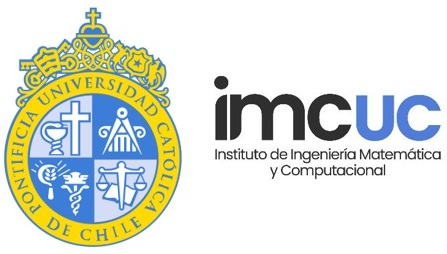
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---

# <h1><center>Actividad 09 - Aprendizaje supervisado: regresiones</center></h1>

Esta actividad busca aplicar distintos tipos de regresiones simples y comprender su comportamiento.

## Instrucciones

Este Notebook contiene las instrucciones a realizar para la actividad. 

<b>Al finalizarla, deben subir el Notebook al módulo de la Actividad 09 en Canvas.</b>

## Contexto

El **porcentaje de grasa corporal** es el porcentaje de la masa total de una persona que corresponde a tejido graso. Este es un indicador de la condición física de la persona y suele ser más informativo que otros indicadores ampliamente utilizados, como por ejemplo el índice de masa corporal (IMC). 

Sin embargo, a diferencia del IMC, que se calcula únicamente a partir de la altura y el peso de la persona, no es tan directo obtener una medición precisa del porcentaje de grasa corporal. Algunos métodos usados son el pesaje subacuático, el ánalisis de impedancia biométrico (o bioimpedancia) y la absorciometría con rayos X. 

Por lo general, los métodos más prácticos de medición son los métodos **antropométricos**, que consisten en la medición de la longitud y circumferencia de distintas partes del cuerpo. Estas permiten estimar a partir de modelos estadísticos (regresiones) la densidad corporal de la persona, la cual, a su vez, se utiliza para calcular el porcentaje de grasa corporal mediante, por ejemplo, la fórmula de Siri:

$BF = (\frac{4.95}{\rho} - 4.50) \cdot 100$

donde $BF$ es el porcentaje de grasa (*body fat*) y $\rho$ es la densidad corporal.

En esta actividad, vamos a utilizar mediciones antropométricas para estimar la densidad corporal de 252 hombres con distintos tipos de regresión vistos en clases. Para esto, utilizaremos el dataset disponible en: https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset

## Rúbrica

- Si han logrado todo: 7.0
- Si han logrado hasta el punto 2.1: 5.0
- Menos que eso: 1.0


## 1. Inspección inicial

### 1.1 Lectura

Cargue el archivo `bodyfat.csv` en un DataFrame.

### 1.2 Correlación entre variables

Muestre un heatmap de la correlación entre todas las mediciones (columnas) de su dataset. ¿Qué puede observar de la relación de densidad corporal con el resto de las mediciones? ¿Y con el porcentaje de grasa corporal? Comente sus observaciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
bodyfat = pd.read_csv('bodyfat.csv')
bodyfat.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


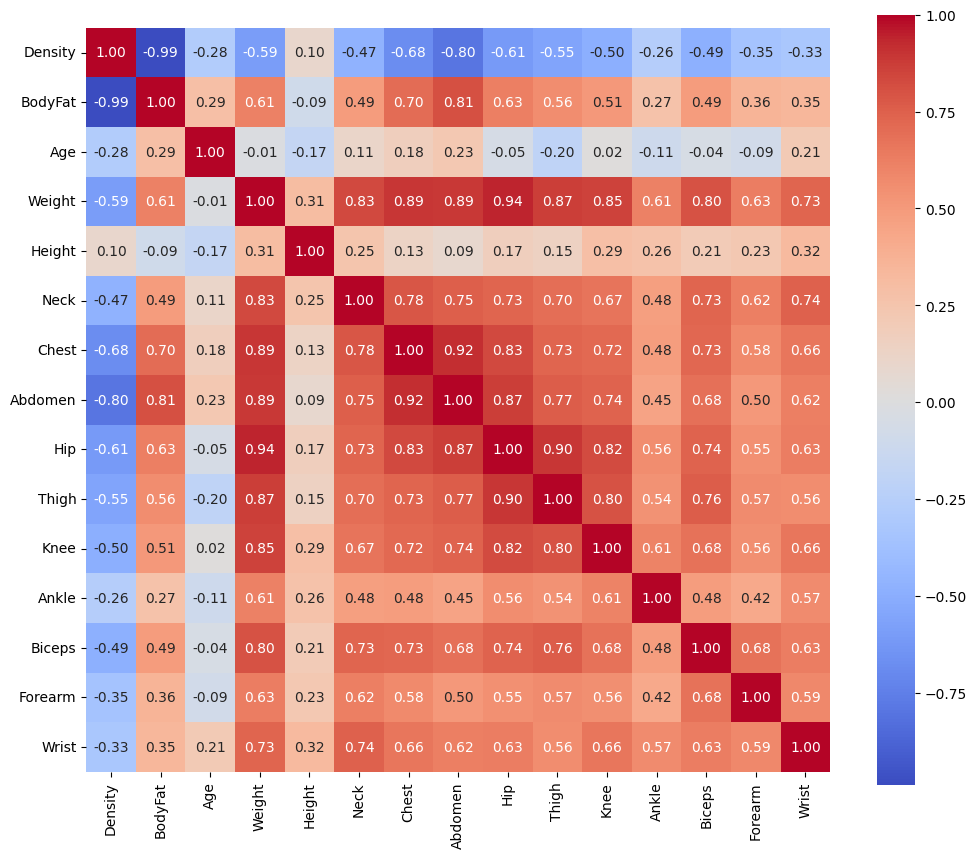

In [3]:
correlaciones = bodyfat.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.show()


Respuesta:
* ***Se puede ver que la densidad tiene una correlación negativa casi perfecta con el porcentaje de grasa corporal, o sea, mientras más denso el cuerpo, menos grasa tiene. También se nota que abdomen, pecho y cadera están bien relacionados con el porcentaje de grasa, así que esas medidas me pueden servir para estimarlo, en cambio, la altura y la edad casi no se relacionan mucho, así que no afectan tanto en la grasa corporal.***

## 2. Regresiones

Ahora vamos a crear nuestra matriz **X** de atributos y nuestro vector **y** (target), el valor a predecir. Para **X**, considere la edad, el peso, la altura y las mediciones antropométricas, mientras que para **y** utilice el porcentaje de grasa corporal.

Luego, separe sus datos en dos sets: uno de entrenamiento y otro de testeo o prueba. Use una división de 80-20, respectivamente.

#### 2.1 Regresión Lineal

**a)** Cree y entrene un modelo de regresión lineal con el set de entrenamiento que definió. Imprima los valores de los coeficientes obtenidos y calcule el RMSE y el $r^2$ de las prediciones del set de entrenamiento y el de prueba.

* ¿Cómo son los valores de RMSE y $r^2$ de estos sets?

**b)** Genere:

* Un scatterplot que compare directamente los valores predecidos (eje X) de los reales (eje Y) para el set de prueba.

* Genere un gráfico residual (*residual plot*) para sus resultados con el set de prueba: esto es, un scatterplot cuyo eje X corresponda a los valores predecidos y su eje Y la diferencia (o residuo) entre los valores reales y los predecidos. (**Hint**: Puede utilizar el método `seaborn.residplot`)

In [4]:
bodyfat = pd.read_csv("bodyfat.csv")

X = bodyfat.drop(columns=["BodyFat"])
y = bodyfat["BodyFat"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"RMSE entrenamiento: {rmse_train:}")
print(f"RMSE prueba: {rmse_test:}")
print(f"R² entrenamiento: {r2_train:}")
print(f"R² prueba: {r2_test:}")

RMSE entrenamiento: 1.3605014842562453
RMSE prueba: 0.6166945836289629
R² entrenamiento: 0.9754034958213557
R² prueba: 0.9918244198502361


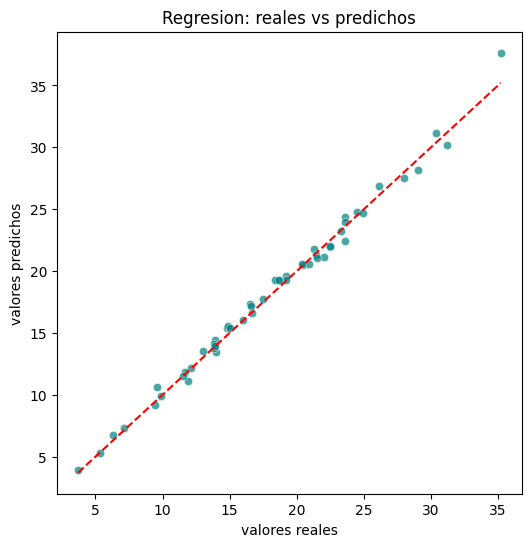

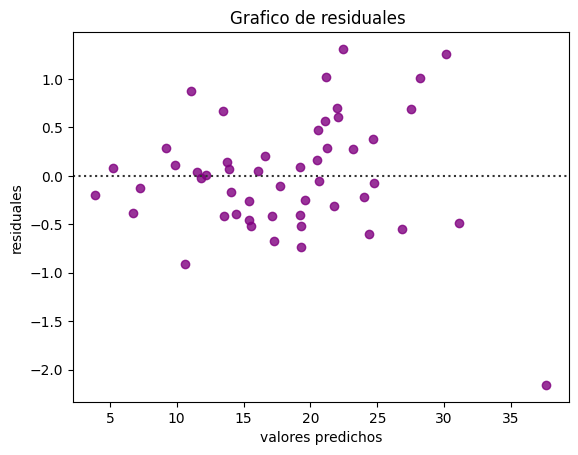

In [8]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_test, color="teal", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("valores reales")
plt.ylabel("valores predichos")
plt.title("Regresion: reales vs predichos")
plt.show()

sns.residplot(x=y_pred_test, y=y_test - y_pred_test, color="purple", line_kws={"color": "black"})
plt.xlabel("valores predichos")
plt.ylabel("residuales")
plt.title("Grafico de residuales ")
plt.show()

respuesta:
* ***El modelo de regresión lineal muestra un ajuste muy bueno. Los valores de R² son cercanos a 1, lo que indica que el modelo explica casi toda la variación del porcentaje de grasa corporal. Además, los RMSE son bajos, por lo que el error entre los valores reales y predichos es pequeño. En el gráfico se observa que los puntos siguen de cerca la línea roja, lo que confirma que las predicciones son bastante precisas.***

#### 2.2 Regresión Polinomial

**a)** Ahora, usando los mismos sets de entrenamiento y prueba, entrene un modelo de regresión polinomial de grado 2. 

Imprima los coeficientes de su modelo y evalúe el desempeño de su modelo mediante las mismas métricas mencionadas anteriormente, tanto para el set de entrenamiento como el de prueba.

* ¿Cómo son los valores de RMSE y $r^2$ de estos sets?
* ¿Cómo es el desempeño de este modelo en comparación con la regresión lineal? Comente porqué cree que ocurre esto.

**b)** Genere:

* Un scatterplot que compare directamente los valores predecidos (eje X) de los reales (eje Y) para el set de prueba.
* Un gráfico residual para sus resultados con el set de prueba.

In [6]:
bodyfat = pd.read_csv("bodyfat.csv")

X = bodyfat.drop(columns=["BodyFat"])
y = bodyfat["BodyFat"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

modelo_poly = LinearRegression()
modelo_poly.fit(X_train_poly, y_train)

y_pred_train_poly = modelo_poly.predict(X_train_poly)
y_pred_test_poly = modelo_poly.predict(X_test_poly)

rmse_train_poly = np.sqrt(mean_squared_error(y_train, y_pred_train_poly))
rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_pred_test_poly))
r2_train_poly = r2_score(y_train, y_pred_train_poly)
r2_test_poly = r2_score(y_test, y_pred_test_poly)

print(f"RMSE entrenamiento: {rmse_train_poly:}")
print(f"RMSE prueba: {rmse_test_poly:}")
print(f"R² entrenamiento: {r2_train_poly:}")
print(f"R² prueba: {r2_test_poly:}")

RMSE entrenamiento: 0.588228034771737
RMSE prueba: 1.4228917330909379
R² entrenamiento: 0.9954020231026914
R² prueba: 0.9564766791642503


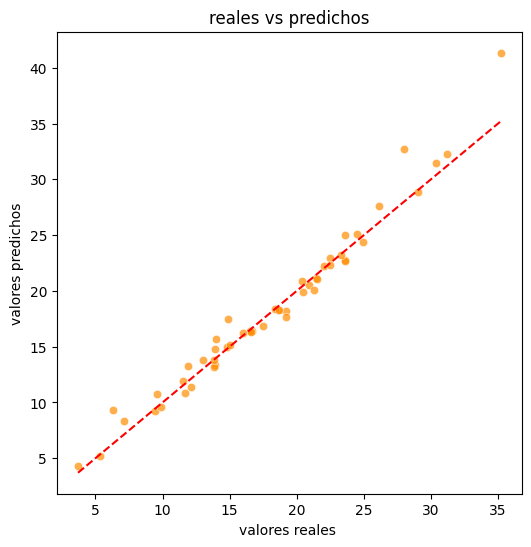

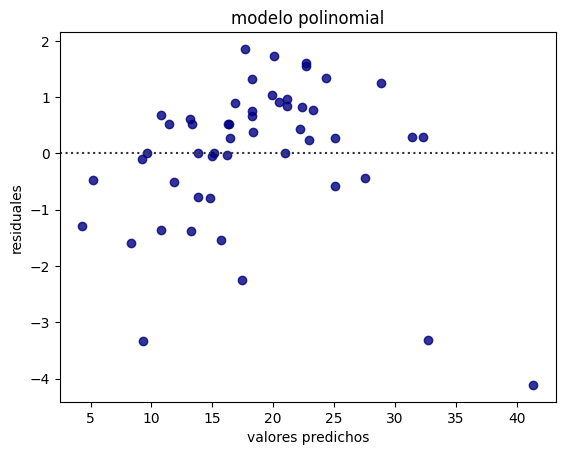

In [7]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_test_poly, color="darkorange", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("valores reales ")
plt.ylabel("valores predichos")
plt.title("reales vs predichos")
plt.show()

sns.residplot(x=y_pred_test_poly, y=y_test - y_pred_test_poly, color="navy", line_kws={"color": "black"})
plt.xlabel("valores predichos")
plt.ylabel("residuales")
plt.title("modelo polinomial")
plt.show()

respuesta
* ***El modelo polinomial muestra un R² muy alto en entrenamiento (0.99), lo que indica que ajusta casi perfectamente esos datos. Sin embargo, en el set de prueba el R² baja a 0.95 y el RMSE aumenta, lo que sugiere que el modelo podría estar sobreajustando. En comparación con la regresión lineal, el modelo polinomial no mejora el rendimiento general, ya que la relación entre las variables parece ser suficientemente lineal. Por esto, el modelo lineal resulta más adecuado y simple para este caso***

#### 2.3 Regresión Lasso

Por último, vamos a repetir nuestro proceso con un modelo de regresión lasso. Primero, queremos encontrar un valor de $\alpha$ ideal para nuestro problema. Vamos a probar con 5 posibles valores: 
$\alpha \in [0.1, 0.5, 1.0, 1.5, 2.0]$

**a)** Cree un modelo de regresión lasso para cada uno de los 5 valores de $\alpha$ entregados y seleccione el mejor valor. Recuerde que para esto, debe evaluar los modelos únicamente con el **set de entrenamiento** y quedarse con el que menor error le entrega.
(**Hint**: Puede hacer esto dentro de un ciclo `for`: asegúrese de ir guardando el mejor valor de $\alpha$)

**b)** Con el mejor valor de `alpha` que haya encontrado, entrene el modelo final e imprima las mismas métricas que para los modelos anteriores, para el set de prueba y el de entrenamiento.

**c)** Finalmente, responda: ¿con cuál de los 3 modelos creados se quedaría para ajustar estos datos?